# 🛒 Retail Analytics Intelligence Platform
### Supermarket Large Dataset — End-to-End Industry-Level Data Science Project

**Author:** Mandhata Pathak
  
**Dataset:** supermarket_large_dataset.csv (120,000 transactions × 323 features)  
**Objective:** Derive actionable business intelligence from retail transaction data through:
- Exploratory Data Analysis (EDA)
- Customer Segmentation (K-Means Clustering)
- Customer Churn Prediction (XGBoost Classifier)
- Sales Forecasting (Time-Series with Prophet)
- Promotion Effectiveness & Gross-Margin Analysis
- Interactive Streamlit Dashboard

---

## 0. Environment Setup

In [3]:
# Install dependencies (run once)
# !pip install -r requirements.txt

In [4]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, silhouette_score,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb

# Time-Series
from prophet import Prophet

# Utilities
import joblib
import os
import json
from datetime import datetime

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Initial Inspection

In [5]:
DATA_PATH = 'supermarket_large_dataset.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape : {df.shape}')
print(f'Rows  : {df.shape[0]:,}')
print(f'Cols  : {df.shape[1]:,}')
df.head(3)

Shape : (120000, 323)
Rows  : 120,000
Cols  : 323


,transaction_id,transaction_line_id,basket_id,customer_id,store_id,product_id,employee_id,supplier_id,customer_age,customer_gender,customer_marital_status,customer_education,customer_occupation,customer_income,household_size,number_of_children,customer_segment,customer_region,customer_city,customer_area_type,urban_rural,customer_membership_status,membership_tier,customer_since_year,customer_tenure_months,...,employee_shift,employee_performance_score,employee_customer_service_score,competitor_count,competitor_average_price,competitor_discount_rate,competitor_distance_km,market_competition_index,relative_price_index,local_average_income,local_unemployment_rate,consumer_confidence_index,inflation_index,food_price_index,economic_condition,units_sold,sales_revenue,profit_per_unit,profit_margin,sales_rank,category_sales_rank,product_popularity,product_growth_rate,product_return_rate,product_stockout_rate
0,T00000001,TL00000001,B00044698,C00106069,S00000108,P00003814,E00000421,SUP00000007,60,Female,Single,Bachelor,Technician,250000.0000,5,1,Regular Shopper,South,City C,Suburban,Suburban,Active,Platinum,2010,170,...,Evening,9.3000,4.5000,2,16.5800,0.2400,9.2000,0.8990,0.6070,249140.3900,0.0770,87.4000,3.4300,92.8000,Stable,10,100.6000,4.6500,0.4620,883,10,5.6000,0.0640,0.0580,0.0293
1,T00000002,TL00000002,B00013390,C00027234,S00000154,P00003904,E00000310,SUP00000035,54,Male,Single,Master,Student,250000.0000,3,2,Regular Shopper,East,City E,Suburban,Suburban,Active,Silver,2022,35,...,Evening,7.4000,6.2000,1,5.8500,0.2900,7.9000,0.3760,3.0670,278463.5500,0.0460,91.6000,2.1700,114.1000,Weak,6,96.9000,8.6600,0.5360,599,29,6.0000,-0.0250,0.0071,0.0028
2,T00000003,TL00000003,B00014357,C00019781,S00000136,P00000650,E00000344,SUP00000022,52,Male,Married,Bachelor,Retired,250000.0000,2,0,Budget Shopper,West,City C,Suburban,Suburban,Active,Gold,2017,91,...,Evening,5.9000,8.1000,6,14.0200,0.0500,2.9000,0.3750,1.7460,272027.5100,0.0610,99.7000,1.9900,103.8000,Moderate,6,132.1800,7.9000,0.3590,389,49,5.2000,-0.0380,0.0029,0.0553


In [6]:
# Data types overview
type_counts = df.dtypes.value_counts()
print('Column data types:')
print(type_counts)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Column data types:
str        143
float64    103
int64       77
Name: count, dtype: int64

Memory usage: 403.6 MB


In [7]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(f'Columns with missing values: {len(missing_df)}')
missing_df.head(20)

Columns with missing values: 28


,missing_count,missing_%
complaint_category,116429,97.0200
return_condition,116327,96.9400
refund_method,116327,96.9400
return_reason,116327,96.9400
holiday_type,110385,91.9900
holiday_name,110385,91.9900
special_event,101820,84.8500
promotion_id,77739,64.7800
promotion_channel,77739,64.7800
card_type,53792,44.8300


In [8]:
# Basic descriptive statistics for key numeric columns
key_numeric = ['quantity', 'unit_price', 'total_amount', 'gross_profit',
               'profit_margin_percent', 'customer_age', 'customer_lifetime_value',
               'discount_percent', 'tax_rate']
# Keep only columns that exist
key_numeric = [c for c in key_numeric if c in df.columns]
df[key_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,120000.0000,8.8489,6.0293,1.0000,5.0000,8.0000,11.0000,175.0000
unit_price,120000.0000,10.6287,10.2801,0.6200,4.2700,7.6200,13.3900,129.1500
total_amount,120000.0000,94.0888,126.3006,0.6200,28.8000,57.8800,113.0900,4682.2200
gross_profit,120000.0000,31.4203,47.3353,-156.2400,6.2800,16.9000,39.2400,1118.1600
profit_margin_percent,120000.0000,33.0564,20.4221,-65.8900,22.6800,37.3400,48.0300,60.0000
customer_age,120000.0000,44.7876,14.4357,18.0000,35.0000,45.0000,55.0000,85.0000
customer_lifetime_value,120000.0000,8822.0352,10994.5180,62.3800,2665.1775,5496.6450,10859.0075,452769.1200
discount_percent,120000.0000,12.8164,14.1868,0.0000,0.0000,10.0000,20.0000,50.0000
tax_rate,120000.0000,8.2841,6.1979,0.0000,5.0000,10.0000,10.0000,20.0000


---
## 2. Data Preprocessing & Feature Engineering

In [9]:
# --- Parse datetime ---
df['transaction_datetime'] = pd.to_datetime(df['transaction_datetime'], errors='coerce')
df['transaction_date']     = pd.to_datetime(df['transaction_date'], errors='coerce')

# --- Derived time features ---
df['trans_year']    = df['transaction_datetime'].dt.year
df['trans_month']   = df['transaction_datetime'].dt.month
df['trans_day']     = df['transaction_datetime'].dt.day
df['trans_hour']    = df['transaction_datetime'].dt.hour
df['trans_weekday'] = df['transaction_datetime'].dt.dayofweek   # 0=Mon
df['trans_week']    = df['transaction_datetime'].dt.isocalendar().week.astype(int)

# --- Revenue-related features ---
if 'gross_sales' in df.columns and 'cost_of_goods_sold' in df.columns:
    df['gross_profit_calc'] = df['gross_sales'] - df['cost_of_goods_sold']

# --- Discount flag ---
if 'discount_percent' in df.columns:
    df['has_discount'] = (df['discount_percent'] > 0).astype(int)

# --- Weekend flag ---
df['is_weekend_flag'] = df['trans_weekday'].isin([5, 6]).astype(int)

# --- Customer churn binary target (churn_risk > 0.5 → 1) ---
if 'customer_churn_risk' in df.columns:
    df['churn_label'] = (df['customer_churn_risk'] > 0.5).astype(int)

print('Feature engineering complete.')
print(df[['trans_year','trans_month','trans_hour','has_discount','churn_label']].head())

Feature engineering complete.
   trans_year  trans_month  trans_hour  has_discount  churn_label
0        2023            7           6             0            1
1        2023            5           3             1            1
2        2023           12           8             1            0
3        2023            2           9             0            0
4        2023            6           6             1            1


In [10]:
# Drop columns with >60% missing or purely ID columns that add no signal
high_missing = missing_df[missing_df['missing_%'] > 60].index.tolist()
id_cols = ['transaction_id','transaction_line_id','basket_id','product_id',
           'employee_id','supplier_id']
drop_cols = list(set(high_missing + id_cols))
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
print(f'Remaining columns after drop: {df_clean.shape[1]}')

Remaining columns after drop: 318


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Sales Over Time

In [11]:
daily_sales = (
    df_clean
    .groupby('transaction_date')['total_amount']
    .sum()
    .reset_index()
    .rename(columns={'transaction_date': 'date', 'total_amount': 'daily_revenue'})
)

fig = px.line(
    daily_sales, x='date', y='daily_revenue',
    title='Daily Revenue Over Time',
    labels={'daily_revenue': 'Revenue ($)', 'date': 'Date'},
    template='plotly_white'
)
fig.update_traces(line_color='#2563eb')
fig.show()

### 3.2 Revenue by Product Category

In [12]:
cat_rev = (
    df_clean
    .groupby('product_category')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(15)
)

fig = px.bar(
    cat_rev, x='total_amount', y='product_category',
    orientation='h',
    title='Top 15 Product Categories by Revenue',
    labels={'total_amount': 'Total Revenue ($)', 'product_category': 'Category'},
    color='total_amount', color_continuous_scale='Blues',
    template='plotly_white'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

### 3.3 Customer Demographics

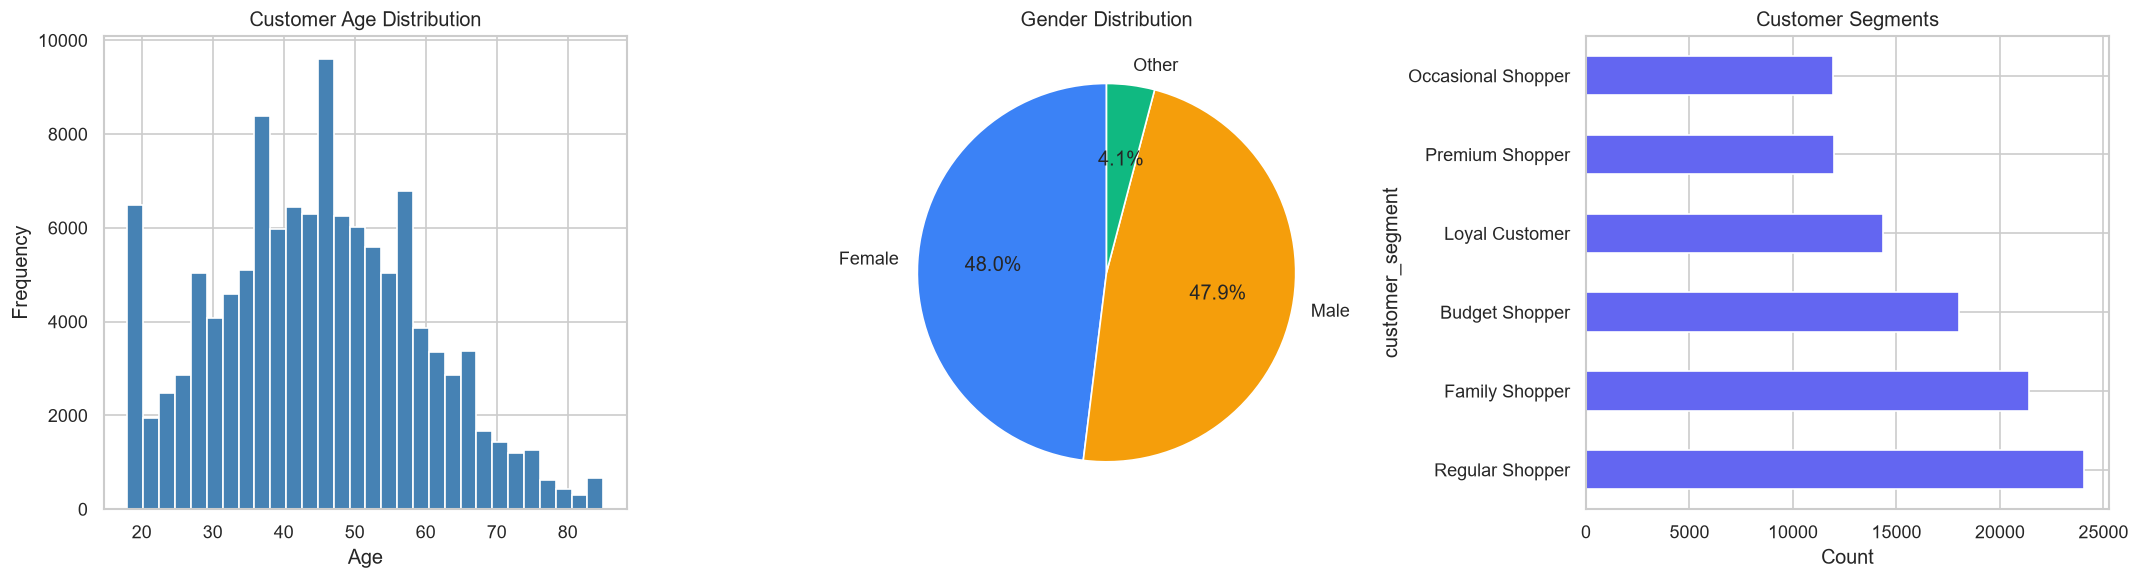

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
df_clean['customer_age'].dropna().plot.hist(
    bins=30, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')

# Gender split
gender_counts = df_clean['customer_gender'].value_counts()
axes[1].pie(
    gender_counts.values, labels=gender_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#3b82f6','#f59e0b','#10b981']
)
axes[1].set_title('Gender Distribution')

# Customer segment
seg_counts = df_clean['customer_segment'].value_counts().head(6)
seg_counts.plot.barh(ax=axes[2], color='#6366f1')
axes[2].set_title('Customer Segments')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_demographics.png', bbox_inches='tight')
plt.show()

### 3.4 Hourly & Weekday Sales Patterns

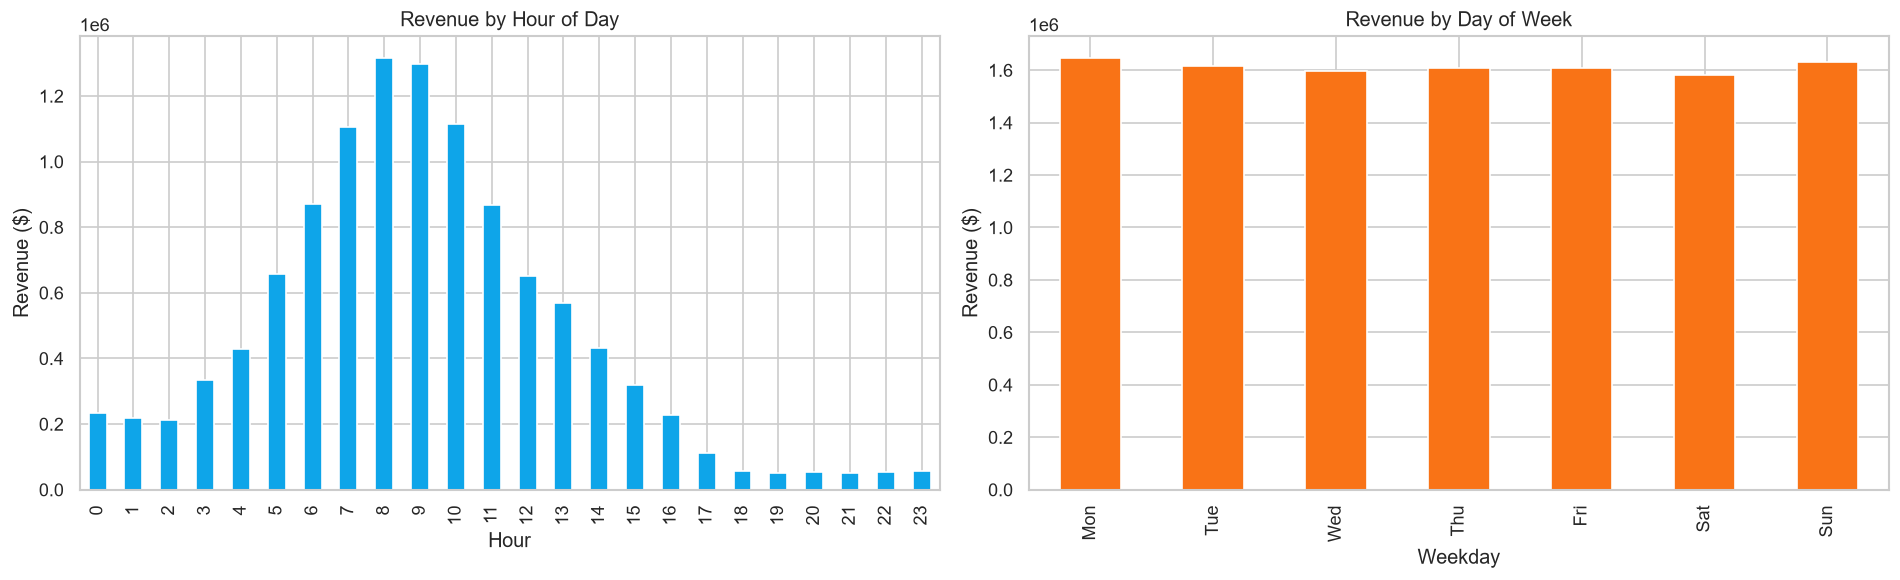

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly
hourly = df_clean.groupby('trans_hour')['total_amount'].sum()
hourly.plot.bar(ax=axes[0], color='#0ea5e9', edgecolor='white')
axes[0].set_title('Revenue by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Revenue ($)')

# Weekday
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
weekday = df_clean.groupby('trans_weekday')['total_amount'].sum()
weekday.index = [day_names[i] for i in weekday.index]
weekday.plot.bar(ax=axes[1], color='#f97316', edgecolor='white')
axes[1].set_title('Revenue by Day of Week')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig('eda_time_patterns.png', bbox_inches='tight')
plt.show()

### 3.5 Profit Margin by Store Type

In [15]:
if 'store_type' in df_clean.columns and 'profit_margin_percent' in df_clean.columns:
    fig = px.box(
        df_clean, x='store_type', y='profit_margin_percent',
        title='Profit Margin Distribution by Store Type',
        color='store_type',
        template='plotly_white'
    )
    fig.update_layout(showlegend=False)
    fig.show()

### 3.6 Correlation Heatmap (Key Numeric Features)

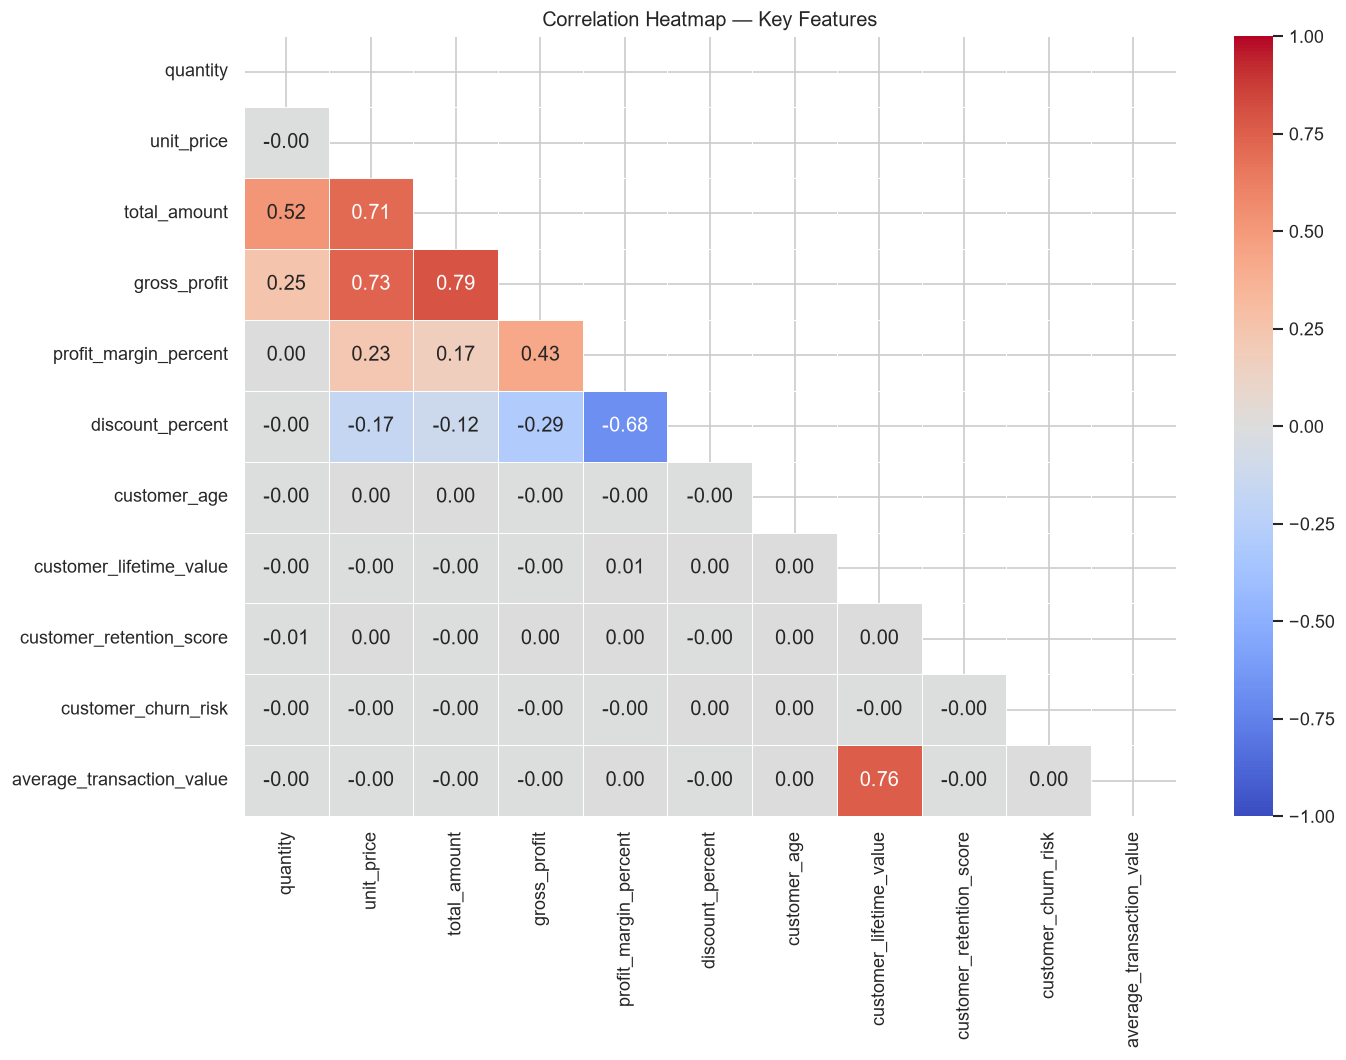

In [16]:
corr_cols = [
    'quantity', 'unit_price', 'total_amount', 'gross_profit',
    'profit_margin_percent', 'discount_percent', 'customer_age',
    'customer_lifetime_value', 'customer_retention_score',
    'customer_churn_risk', 'average_transaction_value'
]
corr_cols = [c for c in corr_cols if c in df_clean.columns]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Correlation Heatmap — Key Features')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

---
## 4. Customer Segmentation — K-Means Clustering (RFM Analysis)

In [17]:
# Build RFM table per customer
snapshot_date = df_clean['transaction_date'].max() + pd.Timedelta(days=1)

rfm = (
    df_clean
    .groupby('customer_id')
    .agg(
        Recency   = ('transaction_date',  lambda x: (snapshot_date - x.max()).days),
        Frequency = ('transaction_date',  'count'),
        Monetary  = ('total_amount',      'sum')
    )
    .reset_index()
)

print(f'RFM table shape: {rfm.shape}')
rfm.describe()

RFM table shape: (75799, 4)


,Recency,Frequency,Monetary
count,75799.0000,75799.0000,75799.0000
mean,305.5786,1.5831,148.9553
std,205.6788,0.8119,176.4053
min,1.0000,1.0000,0.7700
25%,126.0000,1.0000,44.3500
50%,278.0000,1.0000,95.8800
75%,470.0000,2.0000,190.5400
max,730.0000,8.0000,4682.2200


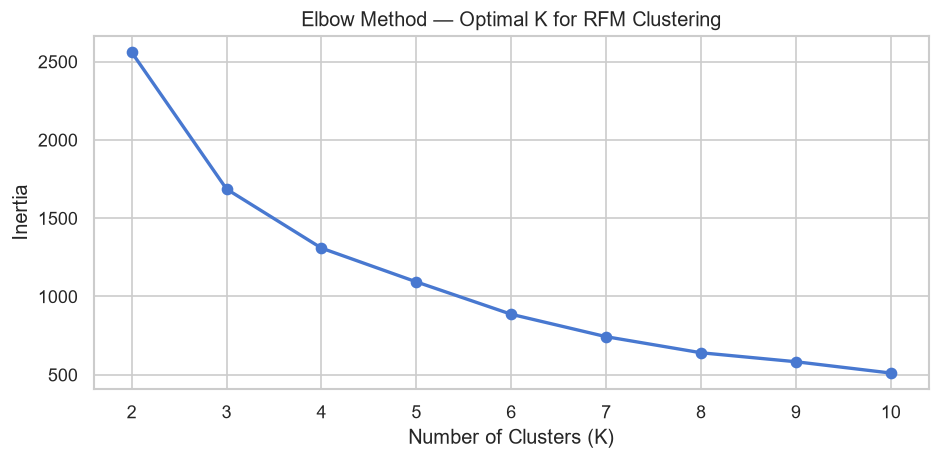

In [18]:
# Scale RFM
scaler_rfm = MinMaxScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow method to choose K
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K for RFM Clustering')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', bbox_inches='tight')
plt.show()

In [19]:
# Fit K=4 (typical retail segmentation)
K_BEST = 4
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init='auto')
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

sil = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f'Silhouette Score (K={K_BEST}): {sil:.4f}')

# Cluster summary
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_summary['Size'] = rfm['Cluster'].value_counts().sort_index()
print('\nCluster Profiles:')
cluster_summary

Silhouette Score (K=4): 0.4048

Cluster Profiles:


,Recency,Frequency,Monetary,Size
Cluster,,,,
0,123.8600,1.0000,93.2700,14749
1,596.1400,1.1600,108.6100,18353
2,112.7300,2.5200,239.4800,19661
3,355.0300,1.4900,139.4900,23036


In [20]:
# Assign business labels based on centroid characteristics
centroid_df = pd.DataFrame(
    scaler_rfm.inverse_transform(km_final.cluster_centers_),
    columns=['Recency','Frequency','Monetary']
)

# Label by Monetary value rank
label_map = {}
sorted_idx = centroid_df['Monetary'].sort_values(ascending=False).index.tolist()
segment_names = ['Champions', 'Loyal Customers', 'At-Risk Customers', 'Lost Customers']
for rank, idx in enumerate(sorted_idx):
    label_map[idx] = segment_names[rank]

rfm['Segment'] = rfm['Cluster'].map(label_map)
print(rfm['Segment'].value_counts())

Segment
Loyal Customers      23036
Champions            19661
At-Risk Customers    18353
Lost Customers       14749
Name: count, dtype: int64


In [21]:
# 3-D scatter of RFM clusters
pca = PCA(n_components=3, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]
rfm['PCA3'] = rfm_pca[:, 2]

fig = px.scatter_3d(
    rfm, x='PCA1', y='PCA2', z='PCA3',
    color='Segment', opacity=0.6,
    title='Customer Segments in PCA Space (RFM Clustering)',
    template='plotly_white'
)
fig.show()

In [22]:
# Radar chart of segment profiles
from plotly.subplots import make_subplots

cats = ['Recency', 'Frequency', 'Monetary']
seg_means = rfm.groupby('Segment')[cats].mean()
seg_means_norm = (seg_means - seg_means.min()) / (seg_means.max() - seg_means.min())

fig = go.Figure()
for seg in seg_means_norm.index:
    vals = seg_means_norm.loc[seg].tolist()
    vals += [vals[0]]  # close the loop
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=cats + [cats[0]],
        fill='toself', name=seg
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title='Customer Segment Radar Chart',
    template='plotly_white'
)
fig.show()

---
## 5. Churn Prediction — XGBoost Classifier

In [23]:
# Select features for churn model
churn_features = [
    'customer_age', 'customer_tenure_months', 'average_monthly_visits',
    'average_transaction_value', 'customer_lifetime_value',
    'customer_retention_score', 'customer_engagement_score',
    'loyalty_points_balance', 'loyalty_points_earned',
    'loyalty_points_redeemed', 'membership_duration_months',
    'number_of_children', 'household_size',
    'has_discount', 'is_weekend_flag'
]

# Encode categorical if present
cat_churn = ['customer_gender', 'customer_segment', 'customer_membership_status',
             'membership_tier', 'customer_education', 'customer_occupation']
cat_churn = [c for c in cat_churn if c in df_clean.columns]

df_churn = df_clean.copy()
le = LabelEncoder()
for col in cat_churn:
    df_churn[col] = le.fit_transform(df_churn[col].astype(str))
    churn_features.append(col)

churn_features = [c for c in churn_features if c in df_churn.columns]
TARGET = 'churn_label'

X = df_churn[churn_features].copy()
y = df_churn[TARGET].copy()

# Impute numerics
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Feature matrix: (120000, 21)
Target distribution:
churn_label
0    100988
1     19012
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Class weight for imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos if pos > 0 else 1.0

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print('\n✅ XGBoost training complete.')

[0]	validation_0-logloss:0.69294
[50]	validation_0-logloss:0.68819
[100]	validation_0-logloss:0.68261
[150]	validation_0-logloss:0.67727
[200]	validation_0-logloss:0.67231
[250]	validation_0-logloss:0.66738
[299]	validation_0-logloss:0.66316

✅ XGBoost training complete.


In [25]:
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.67      0.75     20198
           1       0.16      0.34      0.22      3802

    accuracy                           0.62     24000
   macro avg       0.50      0.50      0.48     24000
weighted avg       0.74      0.62      0.66     24000

ROC-AUC Score : 0.5057


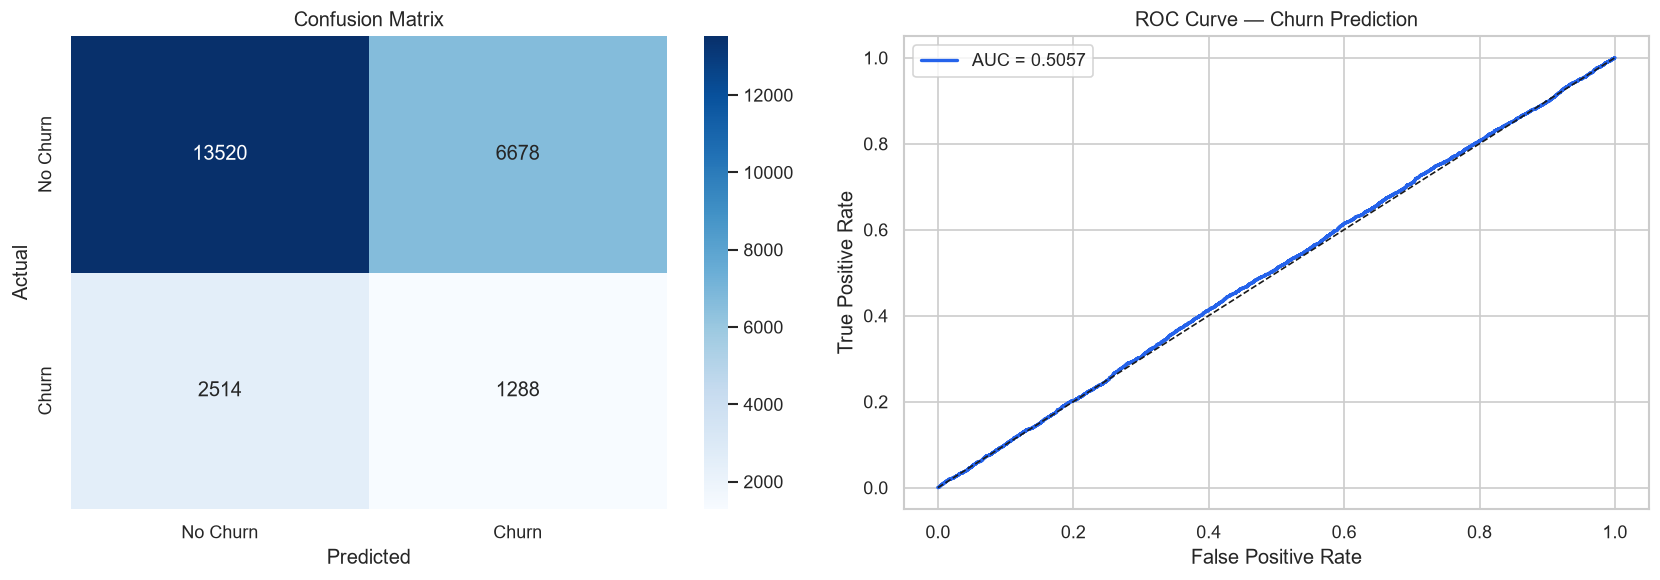

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2563eb', lw=2,
             label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Churn Prediction')
axes[1].legend()

plt.tight_layout()
plt.savefig('churn_model_results.png', bbox_inches='tight')
plt.show()

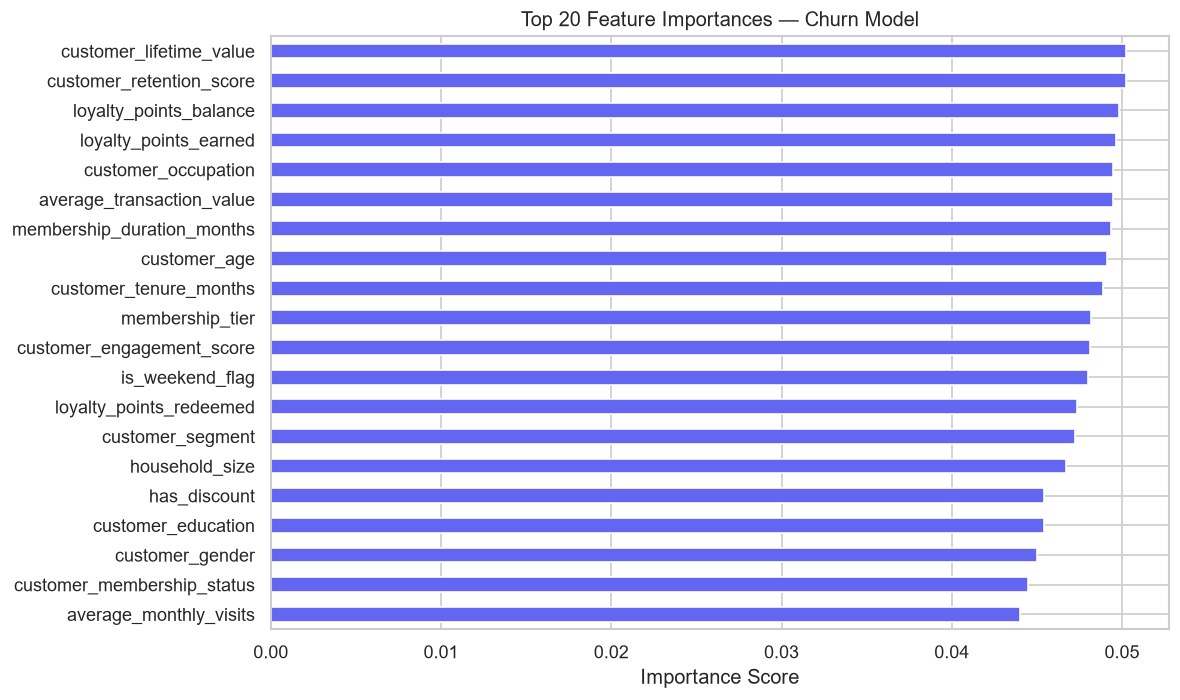

In [27]:
# Feature importance
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=churn_features
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
feat_imp.plot.barh(color='#6366f1')
plt.title('Top 20 Feature Importances — Churn Model')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('churn_feature_importance.png', bbox_inches='tight')
plt.show()

In [28]:
# Save model
joblib.dump(xgb_model, 'churn_model_xgb.pkl')
joblib.dump(imputer,   'churn_imputer.pkl')
print('Models saved.')

Models saved.


---
## 6. Sales Forecasting — Facebook Prophet

In [29]:
# Aggregate daily revenue
prophet_df = (
    df_clean
    .groupby('transaction_date')['total_amount']
    .sum()
    .reset_index()
    .rename(columns={'transaction_date': 'ds', 'total_amount': 'y'})
    .dropna()
    .sort_values('ds')
)
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
print(f'Prophet dataset: {prophet_df.shape}')
print(f'Date range: {prophet_df["ds"].min()} → {prophet_df["ds"].max()}')
prophet_df.tail()

Prophet dataset: (730, 2)
Date range: 2023-01-01 00:00:00 → 2024-12-30 00:00:00


,ds,y
725,2024-12-26,13558.2500
726,2024-12-27,19814.9800
727,2024-12-28,17713.3500
728,2024-12-29,15848.3500
729,2024-12-30,12488.3200


In [30]:
# Train/test split (last 30 days as test)
cutoff = prophet_df['ds'].max() - pd.Timedelta(days=30)
train_prophet = prophet_df[prophet_df['ds'] <= cutoff]
test_prophet  = prophet_df[prophet_df['ds'] >  cutoff]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_mode='multiplicative'
)
model_prophet.fit(train_prophet)
print('Prophet model trained.')

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
16:37:39 - cmdstanpy - INFO - Chain [1] start processing
16:37:39 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained.


In [31]:
# Forecast 60 days into future
future = model_prophet.make_future_dataframe(periods=60, freq='D')
forecast = model_prophet.predict(future)

# Evaluate on test set
test_forecast = forecast[forecast['ds'].isin(test_prophet['ds'])][['ds','yhat']]
merged = test_prophet.merge(test_forecast, on='ds')

mae  = mean_absolute_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
r2   = r2_score(merged['y'], merged['yhat'])
print(f'Forecast MAE  : ${mae:,.2f}')
print(f'Forecast RMSE : ${rmse:,.2f}')
print(f'R² Score      : {r2:.4f}')

Forecast MAE  : $1,926.67
Forecast RMSE : $2,466.31
R² Score      : -0.1263


In [32]:
# Plot forecast
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=prophet_df['ds'], y=prophet_df['y'],
    name='Actual', mode='lines',
    line=dict(color='#3b82f6', width=1.5)
))
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    name='Forecast', mode='lines',
    line=dict(color='#f59e0b', width=2, dash='dash')
))
fig.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(245,158,11,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='Confidence Band'
))
fig.update_layout(
    title='Daily Revenue — Actuals vs Prophet Forecast',
    xaxis_title='Date', yaxis_title='Revenue ($)',
    template='plotly_white', legend=dict(x=0.01, y=0.99)
)
fig.show()

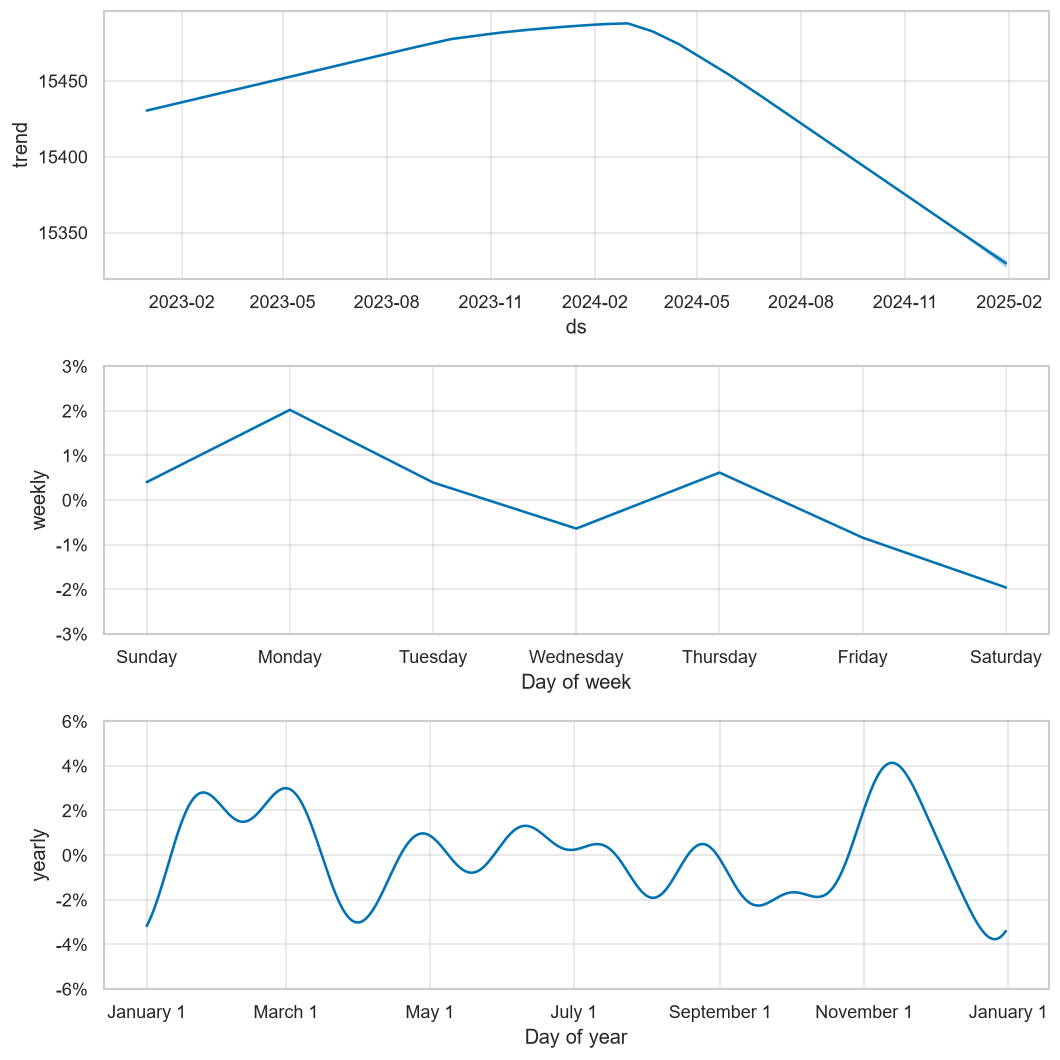

In [33]:
# Seasonality components
model_prophet.plot_components(forecast)
plt.tight_layout()
plt.savefig('prophet_components.png', bbox_inches='tight')
plt.show()

---
## 7. Promotion Effectiveness & Gross-Margin Analysis

Compare realized sales and gross margin across discount bands, promotion status, and product categories. These descriptive comparisons do not establish causal promotion lift.

In [34]:
promotion_df = df_clean[[
    'product_category', 'promotion_active', 'discount_percent',
    'gross_sales', 'gross_profit'
]].dropna(subset=['discount_percent', 'gross_sales', 'gross_profit']).copy()

promotion_df['discount_band'] = pd.cut(
    promotion_df['discount_percent'],
    bins=[-np.inf, 0, 10, 20, 30, 40, np.inf],
    labels=['No discount', '1-10%', '11-20%', '21-30%', '31-40%', 'Over 40%']
)

promotion_discount_summary = (
    promotion_df.groupby('discount_band', observed=False)
    .agg(
        transactions=('gross_sales', 'size'),
        gross_sales=('gross_sales', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        average_discount=('discount_percent', 'mean')
    )
    .reset_index()
)
promotion_discount_summary['gross_margin_pct'] = np.where(
    promotion_discount_summary['gross_sales'] > 0,
    promotion_discount_summary['gross_profit'] / promotion_discount_summary['gross_sales'] * 100,
    0
)

discount_fig = px.bar(
    promotion_discount_summary,
    x='discount_band', y='gross_profit', color='gross_margin_pct',
    hover_data=['transactions', 'gross_sales', 'average_discount'],
    color_continuous_scale='RdYlGn',
    labels={'discount_band': 'Discount band', 'gross_profit': 'Gross profit ($)',
            'gross_margin_pct': 'Gross margin (%)'},
    title='Gross Profit by Discount Band', template='plotly_white'
)
discount_fig.update_layout(coloraxis_showscale=False)
discount_fig.show()

promotion_status_summary = (
    promotion_df.groupby('promotion_active', observed=True)
    .agg(
        transactions=('gross_sales', 'size'),
        gross_sales=('gross_sales', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        average_discount=('discount_percent', 'mean')
    )
)
promotion_status_summary['gross_margin_pct'] = (
    promotion_status_summary['gross_profit'] / promotion_status_summary['gross_sales'] * 100
)
print('Promotion status comparison (descriptive, not causal):')
display(promotion_status_summary.round(2))

promotion_category_summary = (
    promotion_df.groupby('product_category')
    .agg(
        transactions=('gross_sales', 'size'),
        gross_sales=('gross_sales', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        average_discount=('discount_percent', 'mean')
    )
    .reset_index()
)
promotion_category_summary['gross_margin_pct'] = (
    promotion_category_summary['gross_profit'] / promotion_category_summary['gross_sales'] * 100
)
promotion_category_summary = promotion_category_summary.sort_values(
    ['gross_margin_pct', 'average_discount'], ascending=[True, False]
)
print('Lowest-margin categories for promotion review:')
display(promotion_category_summary.head(15).round(2))

Promotion status comparison (descriptive, not causal):


,transactions,gross_sales,gross_profit,average_discount,gross_margin_pct
promotion_active,,,,,
No,77739,7736223.0800,2446045.4600,12.7700,31.6200
Yes,42261,4184464.4500,1324396.3700,12.9000,31.6500


Lowest-margin categories for promotion review:


,product_category,transactions,gross_sales,gross_profit,average_discount,gross_margin_pct
19,Kidswear,1504,169792.7700,36702.0300,14.4600,21.6200
8,Coffee,1886,180943.1000,44449.9000,12.2900,24.5700
25,Medical Devices,1946,204151.5300,55694.2500,13.9700,27.2800
23,Lighting,1668,145074.2500,40687.3400,14.6000,28.0500
5,Bedding,1587,167932.3000,47133.6900,15.4900,28.0700
11,Diapers,2201,269817.8100,77605.2200,11.8900,28.7600
2,Baby Food,1912,201600.8400,58074.5200,10.5900,28.8100
38,Storage,3427,301024.7700,86937.8200,14.2700,28.8800
33,Pet Toys,2102,226977.3800,66570.5000,14.3500,29.3300
15,Fruits,5775,545387.0700,161438.6300,13.5200,29.6000


---
## 8. Business Insights Dashboard (KPI Summary)

In [35]:
# ---------- KPI Computations ----------
total_revenue   = df_clean['total_amount'].sum()
total_txns      = df_clean['transaction_id'].nunique() if 'transaction_id' in df_clean.columns else len(df_clean)
avg_basket      = df_clean.groupby('basket_id')['total_amount'].sum().mean() if 'basket_id' in df_clean.columns else df_clean['total_amount'].mean()
total_customers = df_clean['customer_id'].nunique()
avg_margin      = df_clean['profit_margin_percent'].mean() if 'profit_margin_percent' in df_clean.columns else 0
churn_rate      = df_clean['churn_label'].mean() * 100

kpis = {
    'Total Revenue ($)':        f'${total_revenue:,.0f}',
    'Total Transactions':       f'{total_txns:,}',
    'Avg Basket Value ($)':     f'${avg_basket:,.2f}',
    'Unique Customers':         f'{total_customers:,}',
    'Avg Profit Margin (%)':    f'{avg_margin:.1f}%',
    'Predicted Churn Rate (%)': f'{churn_rate:.1f}%',
}

print('=' * 45)
print('     RETAIL ANALYTICS — KEY METRICS')
print('=' * 45)
for k, v in kpis.items():
    print(f'  {k:<32} {v}')
print('=' * 45)

     RETAIL ANALYTICS — KEY METRICS
  Total Revenue ($)                $11,290,659
  Total Transactions               120,000
  Avg Basket Value ($)             $94.09
  Unique Customers                 75,799
  Avg Profit Margin (%)            33.1%
  Predicted Churn Rate (%)         15.8%


In [36]:
# Monthly revenue bar chart
monthly = (
    df_clean
    .assign(month_period=df_clean['transaction_date'].dt.to_period('M'))
    .groupby('month_period')['total_amount']
    .sum()
    .reset_index()
)
monthly['month_period'] = monthly['month_period'].astype(str)

fig = px.bar(
    monthly, x='month_period', y='total_amount',
    title='Monthly Revenue Trend',
    labels={'month_period': 'Month', 'total_amount': 'Revenue ($)'},
    color='total_amount', color_continuous_scale='Blues',
    template='plotly_white'
)
fig.show()

In [37]:
# Top 10 cities by revenue
if 'city' in df_clean.columns:
    city_rev = (
        df_clean.groupby('city')['total_amount']
        .sum().sort_values(ascending=False).head(10).reset_index()
    )
    fig = px.bar(
        city_rev, x='city', y='total_amount',
        title='Top 10 Cities by Revenue',
        labels={'city': 'City', 'total_amount': 'Revenue ($)'},
        color='total_amount', color_continuous_scale='Teal',
        template='plotly_white'
    )
    fig.show()

In [38]:
# Save KPIs for dashboard
with open('kpis.json', 'w') as f:
    json.dump(kpis, f, indent=2)
print('KPIs saved to kpis.json')

KPIs saved to kpis.json


---
## 9. Streamlit Dashboard App

The dashboard is maintained in `app.py`. Run `streamlit run app.py` from the project directory.

In [39]:
print('The dashboard is maintained in app.py. Run it with: streamlit run app.py')

The dashboard is maintained in app.py. Run it with: streamlit run app.py


---
## 10. Final Summary & Conclusions

In [40]:
print("""
RETAIL ANALYTICS INTELLIGENCE PLATFORM

Dataset: supermarket_large_dataset.csv
Records: 120,000 transactions x 323 features

Modules:
1. Data loading and inspection
2. Preprocessing and feature engineering
3. Exploratory data analysis
4. Customer segmentation (RFM / K-Means)
5. Churn prediction (XGBoost)
6. Sales forecasting (Prophet)
7. Promotion effectiveness and gross-margin analysis
8. KPI business insights dashboard
9. Streamlit dashboard (app.py)

Run the dashboard with: streamlit run app.py
""")


RETAIL ANALYTICS INTELLIGENCE PLATFORM

Dataset: supermarket_large_dataset.csv
Records: 120,000 transactions x 323 features

Modules:
1. Data loading and inspection
2. Preprocessing and feature engineering
3. Exploratory data analysis
4. Customer segmentation (RFM / K-Means)
5. Churn prediction (XGBoost)
6. Sales forecasting (Prophet)
7. Promotion effectiveness and gross-margin analysis
8. KPI business insights dashboard
9. Streamlit dashboard (app.py)

Run the dashboard with: streamlit run app.py

